### Imports

In [2]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder, LabelEncoder
from sklearn.compose import ColumnTransformer
from sklearn.metrics import classification_report
from sklearn.utils.class_weight import compute_class_weight

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sb

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.callbacks import EarlyStopping

### Preprocessing

In [3]:
# Load the dataset
df = pd.read_csv('predictive_maintenance.csv')

# Encode the target
label_encoder = LabelEncoder()
df['Failure Type Encoded'] = label_encoder.fit_transform(df['Failure Type'])

# Define features and target
x = df.drop(columns=['UDI', 'Product ID', 'Failure Type', 'Target'])
y = df['Failure Type Encoded']

# Split the data
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42)

# Preprocess
categorical_features = ['Type']
numeric_features = x.drop(columns=categorical_features).columns.tolist()

preprocessor = ColumnTransformer([
    ('num', StandardScaler(), numeric_features),
    ('cat', OneHotEncoder(drop='first'), categorical_features)
])

# Fit and transform
x_train = preprocessor.fit_transform(x_train)
x_test = preprocessor.transform(x_test)


### Neural Network

In [4]:
# One-hot encode y
num_classes = len(label_encoder.classes_)
y_train_oh = to_categorical(y_train, num_classes=num_classes)
y_test_oh = to_categorical(y_test, num_classes=num_classes)

# Define model
model = Sequential([
    Dense(64, activation='relu'),
    Dropout(0.3),
    Dense(64, activation='relu'),
    Dropout(0.3),
    Dense(num_classes, activation='softmax')
])


In [ ]:
model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])
early_stop = EarlyStopping(monitor='val_loss', patience=20, restore_best_weights=True)

history = model.fit(
    x_train, y_train_oh,
    validation_split=0.2,
    epochs=400,
    batch_size=32,
    verbose=1,
    callbacks=early_stop
)

Epoch 1/400
200/200 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - accuracy: 0.8427 - loss: 0.7956 - val_accuracy: 0.9681 - val_loss: 0.1320
Epoch 2/400
200/200 ━━━━━━━━━━━━━━━━━━━━ 0s 971us/step - accuracy: 0.9711 - loss: 0.1207 - val_accuracy: 0.9850 - val_loss: 0.0446
Epoch 3/400
200/200 ━━━━━━━━━━━━━━━━━━━━ 0s 986us/step - accuracy: 0.9840 - loss: 0.0507 - val_accuracy: 0.9944 - val_loss: 0.0246
Epoch 4/400
200/200 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.9899 - loss: 0.0332 - val_accuracy: 0.9975 - val_loss: 0.0144
Epoch 5/400
200/200 ━━━━━━━━━━━━━━━━━━━━ 0s 966us/step - accuracy: 0.9914 - loss: 0.0266 - val_accuracy: 0.9962 - val_loss: 0.0119
Epoch 6/400
200/200 ━━━━━━━━━━━━━━━━━━━━ 0s 964us/step - accuracy: 0.9923 - loss: 0.0217 - val_accuracy: 0.9975 - val_loss: 0.0088
Epoch 7/400
200/200 ━━━━━━━━━━━━━━━━━━━━ 0s 935us/step - accuracy: 0.9966 - loss: 0.0121 - val_accuracy: 0.9981 - val_loss: 0.0084
Epoch 8/400
200/200 ━━━━━━━━━━━━━━━━━━━━ 0s 947us/step - accuracy: 0.9958 - loss: 0.016

### Plot Losses

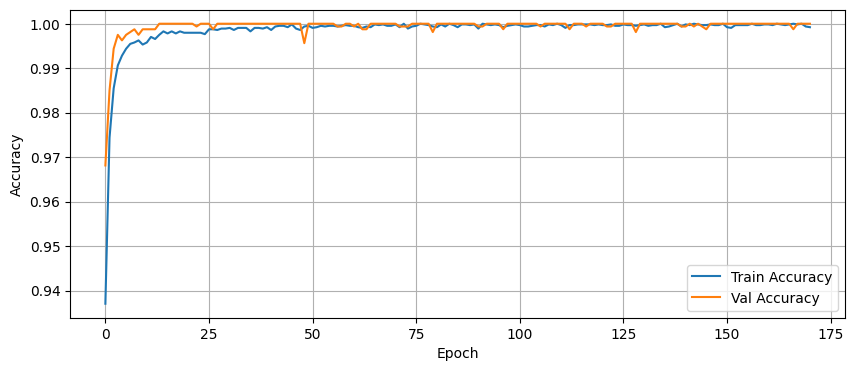

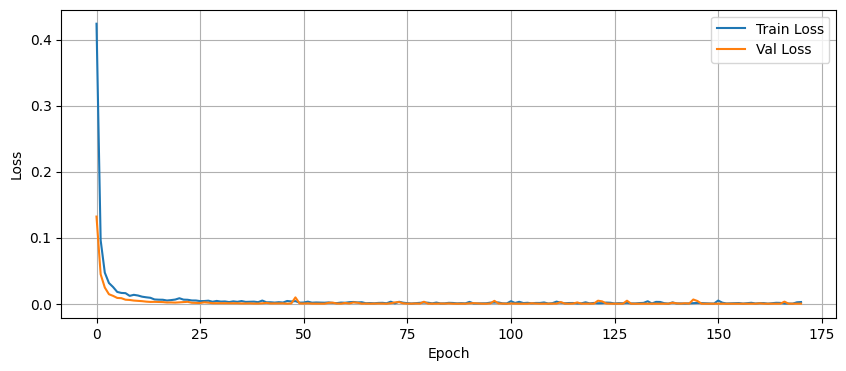

In [6]:
# Accuracy
plt.figure(figsize=(10, 4))
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Val Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)
plt.show()

# Loss
plt.figure(figsize=(10, 4))
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Val Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)
plt.show()

### Final Test

In [264]:
# DO NOT use this report for tuning
y_pred_probs = model.predict(x_test)
y_pred = np.argmax(y_pred_probs, axis=1)

print(classification_report(y_test, y_pred, target_names=label_encoder.classes_))

63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 837us/step
                          precision    recall  f1-score   support

Heat Dissipation Failure       1.00      1.00      1.00        15
              No Failure       1.00      1.00      1.00      1935
      Overstrain Failure       1.00      1.00      1.00        13
           Power Failure       1.00      1.00      1.00        20
         Random Failures       0.67      0.33      0.44         6
       Tool Wear Failure       0.71      0.91      0.80        11

                accuracy                           1.00      2000
               macro avg       0.90      0.87      0.87      2000
            weighted avg       1.00      1.00      1.00      2000



### Update  Class Weights

In [201]:
# One-hot encode y
num_classes = len(label_encoder.classes_)
y_train_oh = to_categorical(y_train, num_classes=num_classes)
y_test_oh = to_categorical(y_test, num_classes=num_classes)

# Define model
balanced_model = Sequential([
    Dense(64, activation='relu', input_shape=(x_train.shape[1],)),
    Dropout(0.3),
    Dense(64, activation='relu'),
    Dropout(0.3),
    Dense(num_classes, activation='softmax')
])


c:\Users\caide\uv_projects\turbofan_nn\.venv\Lib\site-packages\keras\src\layers\core\dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [208]:
weights = compute_class_weight(class_weight='balanced', classes=np.unique(y_train), y=y_train)
class_weight_dict = dict(enumerate(weights))
early_stop = EarlyStopping(monitor='val_loss', patience=40, restore_best_weights=True)

balanced_model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])

balanced_history = balanced_model.fit(
    x_train, y_train,
    validation_split=0.2,
    epochs=300,
    batch_size=32,
    class_weight=class_weight_dict,
    callbacks=[early_stop],
    verbose=1
)

Epoch 1/300
200/200 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - accuracy: 0.9989 - loss: 0.0441 - val_accuracy: 1.0000 - val_loss: 5.9444e-05
Epoch 2/300
200/200 ━━━━━━━━━━━━━━━━━━━━ 0s 934us/step - accuracy: 0.9996 - loss: 0.0035 - val_accuracy: 0.9987 - val_loss: 0.0088
Epoch 3/300
200/200 ━━━━━━━━━━━━━━━━━━━━ 0s 926us/step - accuracy: 0.9993 - loss: 0.0646 - val_accuracy: 0.9994 - val_loss: 0.0048
Epoch 4/300
200/200 ━━━━━━━━━━━━━━━━━━━━ 0s 932us/step - accuracy: 0.9990 - loss: 0.0161 - val_accuracy: 1.0000 - val_loss: 3.6308e-04
Epoch 5/300
200/200 ━━━━━━━━━━━━━━━━━━━━ 0s 950us/step - accuracy: 0.9994 - loss: 0.0282 - val_accuracy: 1.0000 - val_loss: 1.4336e-04
Epoch 6/300
200/200 ━━━━━━━━━━━━━━━━━━━━ 0s 921us/step - accuracy: 0.9988 - loss: 0.0786 - val_accuracy: 1.0000 - val_loss: 4.3324e-05
Epoch 7/300
200/200 ━━━━━━━━━━━━━━━━━━━━ 0s 913us/step - accuracy: 0.9995 - loss: 0.0017 - val_accuracy: 1.0000 - val_loss: 4.5050e-05
Epoch 8/300
200/200 ━━━━━━━━━━━━━━━━━━━━ 0s 946us/step - accuracy

### Plot Losses for Balanced Classes

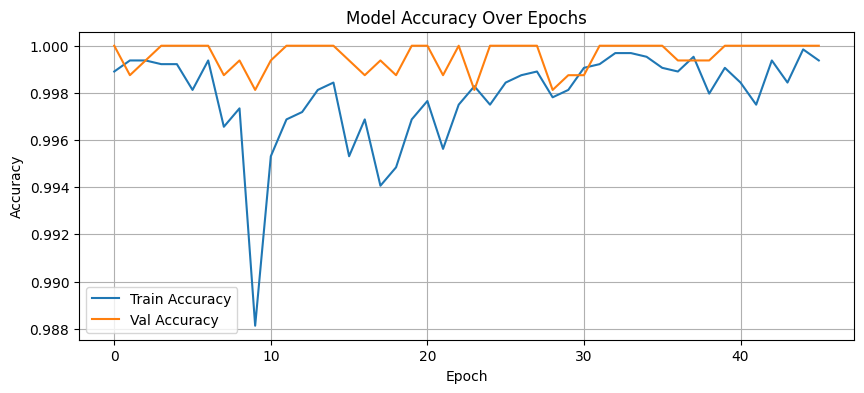

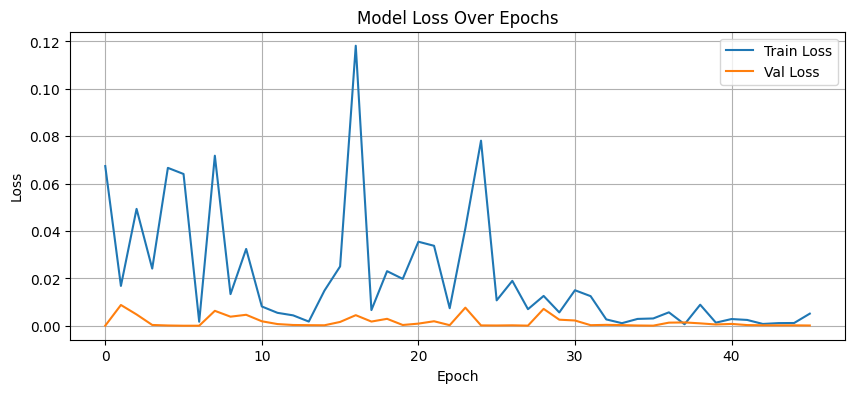

In [210]:
### Plot Losses for Balanced Classes
# Accuracy
plt.figure(figsize=(10, 4))
plt.plot(balanced_history.history['accuracy'], label='Train Accuracy')
plt.plot(balanced_history.history['val_accuracy'], label='Val Accuracy')
plt.title('Model Accuracy Over Epochs')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)
plt.show()

# Loss
plt.figure(figsize=(10, 4))
plt.plot(balanced_history.history['loss'], label='Train Loss')
plt.plot(balanced_history.history['val_loss'], label='Val Loss')
plt.title('Model Loss Over Epochs')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)
plt.show()

### Final Balanced Model Test

In [209]:
y_pred_probs = balanced_model.predict(x_test)
y_pred = np.argmax(y_pred_probs, axis=1)

print(classification_report(y_test, y_pred, target_names=label_encoder.classes_))

63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 802us/step
                          precision    recall  f1-score   support

Heat Dissipation Failure       1.00      1.00      1.00        15
              No Failure       1.00      1.00      1.00      1935
      Overstrain Failure       1.00      1.00      1.00        13
           Power Failure       1.00      1.00      1.00        20
         Random Failures       0.67      0.33      0.44         6
       Tool Wear Failure       0.71      0.91      0.80        11

                accuracy                           1.00      2000
               macro avg       0.90      0.87      0.87      2000
            weighted avg       1.00      1.00      1.00      2000

